In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from machine_learning.transform_dataset_ml import transform_dataset
from machine_learning.create_ml_dataset import create_dataset_from_all_file
import numpy as np
import pandas as pd


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from typing import Dict, Any



from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer




In [2]:
ml_dataset = create_dataset_from_all_file()

Machine learning dataset create


# trasnform dataset

In [3]:
encode_dataset, X, y, label_encoder = transform_dataset(ml_dataset.copy())

### descriptive info dataset

In [4]:
encode_dataset.shape

(198, 41)

In [5]:
encode_dataset.describe()

,date_bourse,open_price,close_price,low_price,high_price,mean_sell,mean_strongBuy,mean_strongSell,insider_sentiment,company_posit_dist_percet,...,decision_score,analyst_mean_sentiment_distribution,analyst_positif_sentiment_distribution,analyst_negatif_sentiment_distribution,current_price,high_price_target,low_price_target,mean_price_target,median_price_target,date_weight
count,198,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,...,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,2025-07-31 08:43:38.181818112,191.384246,191.345474,189.045371,193.509223,0.104242,0.825758,0.070758,-0.333333,0.524054,...,1.899960,0.574394,0.641009,0.291947,191.345538,270.259495,133.984848,204.409356,207.767879,-9.000000
min,2025-07-09 00:00:00,23.299999,23.305000,23.110001,23.520000,0.000000,0.430000,0.000000,-1.000000,0.313253,...,-9.587000,0.100000,0.200000,0.034500,23.305000,37.800000,23.000000,28.657140,28.000000,-25.000000
25%,2025-07-21 00:00:00,90.988747,91.249998,89.599998,92.790003,0.000000,0.690000,0.000000,-1.000000,0.448790,...,-1.036750,0.210000,0.413800,0.066700,91.250000,115.000000,64.000000,98.724140,100.000000,-17.000000
50%,2025-07-31 00:00:00,97.056813,97.064999,95.358450,98.057499,0.000000,0.915000,0.050000,-1.000000,0.526121,...,1.576000,0.570000,0.612500,0.307700,97.065000,135.500000,77.500000,112.233555,113.750000,-9.000000
75%,2025-08-12 00:00:00,321.602501,321.925011,316.042503,324.787468,0.210000,1.000000,0.150000,1.000000,0.587728,...,4.925250,0.930000,0.933300,0.379300,321.925000,500.000000,115.000000,306.320740,321.875000,-1.000000
max,2025-08-22 00:00:00,555.224976,537.039978,532.530029,555.450012,0.420000,1.000000,0.170000,1.000000,0.900000,...,13.904000,0.970000,0.965500,0.700000,537.040000,700.000000,483.000000,613.294740,630.000000,7.000000
std,NaN,172.809982,172.299037,171.025078,174.108711,0.160321,0.210677,0.073574,0.945199,0.096410,...,3.890458,0.326699,0.265302,0.213259,172.299033,243.060384,143.782813,185.803213,189.246449,9.546041


#### hist

array([[<Axes: title={'center': 'date_bourse'}>,
        <Axes: title={'center': 'open_price'}>,
        <Axes: title={'center': 'close_price'}>,
        <Axes: title={'center': 'low_price'}>,
        <Axes: title={'center': 'high_price'}>,
        <Axes: title={'center': 'mean_sell'}>],
       [<Axes: title={'center': 'mean_strongBuy'}>,
        <Axes: title={'center': 'mean_strongSell'}>,
        <Axes: title={'center': 'insider_sentiment'}>,
        <Axes: title={'center': 'company_posit_dist_percet'}>,
        <Axes: title={'center': 'company_negat_dist_percet'}>,
        <Axes: title={'center': 'country_posit_dist_percet'}>],
       [<Axes: title={'center': 'country_negat_dist_percet'}>,
        <Axes: title={'center': 'volume_action'}>,
        <Axes: title={'center': 'this_month_most_direction'}>,
        <Axes: title={'center': 'last_month_most_direction'}>,
        <Axes: title={'center': 'year_to_date_direction'}>,
        <Axes: title={'center': 'one_year_rolling_period_most

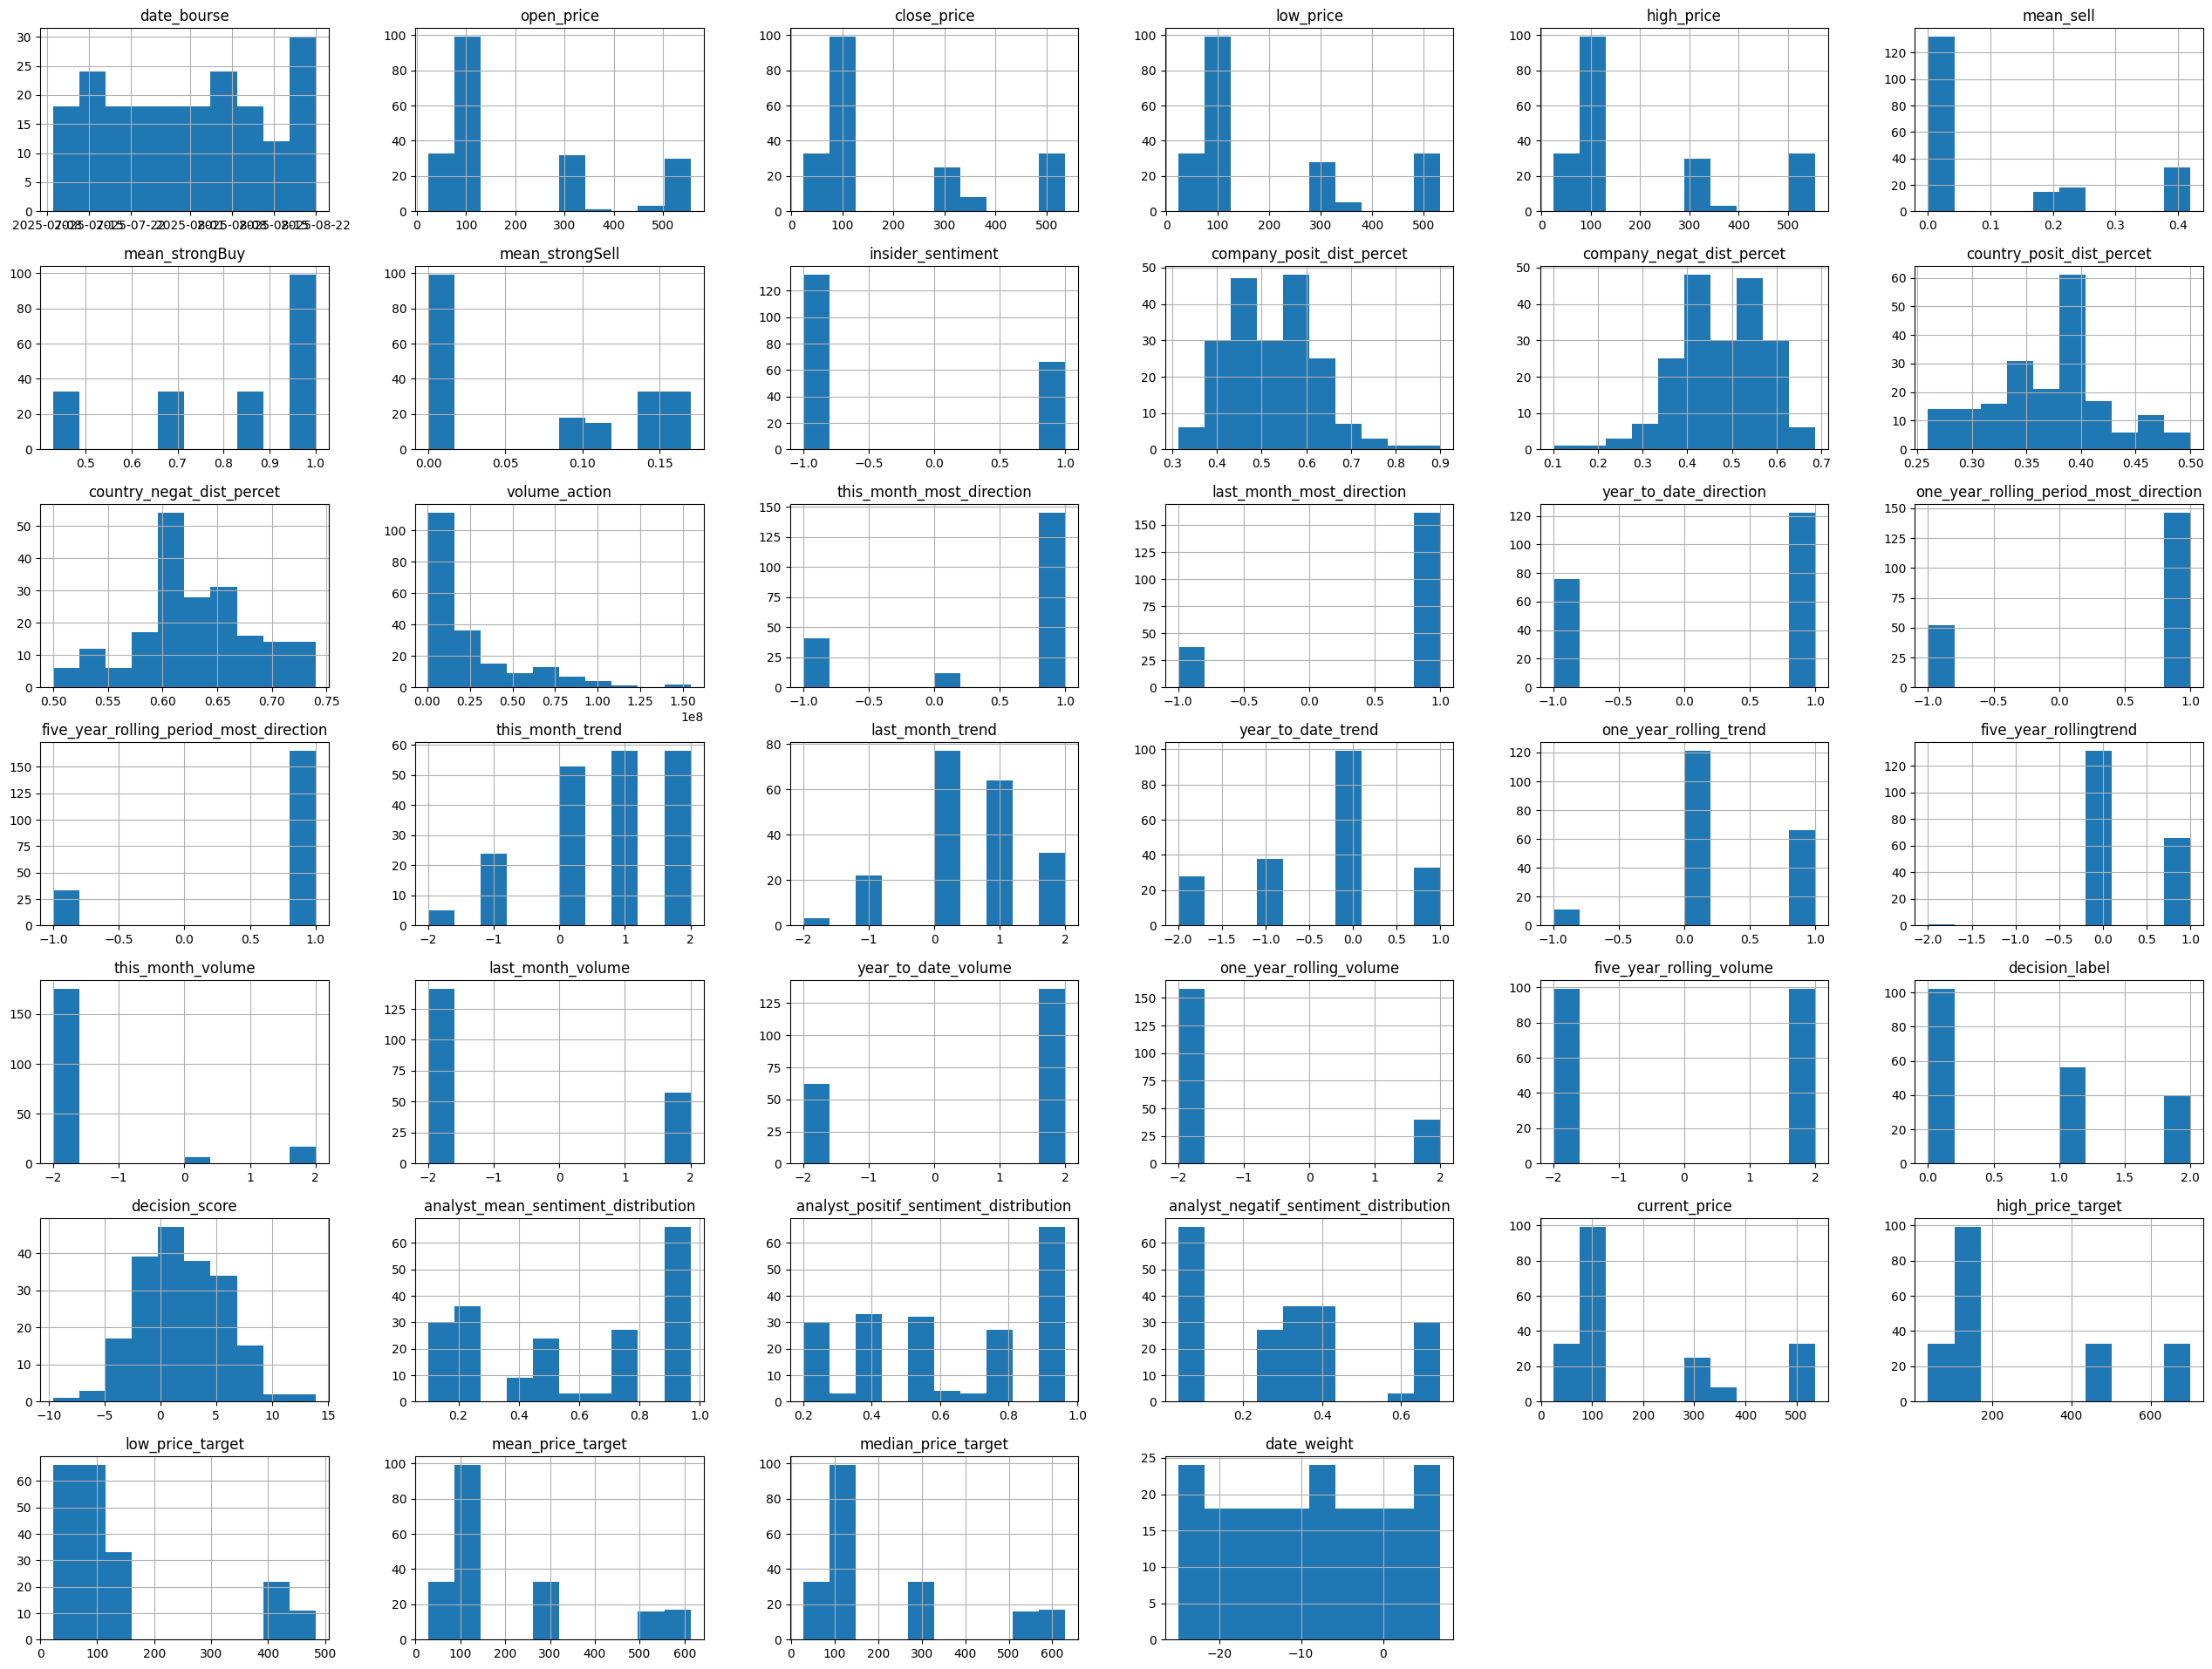

In [6]:
encode_dataset.hist(figsize=(8*4, 6*4))

#### plot

open_price                                     Axes(0.125,0.77;0.0945122x0.11)
close_price                                 Axes(0.238415,0.77;0.0945122x0.11)
low_price                                   Axes(0.351829,0.77;0.0945122x0.11)
high_price                                  Axes(0.465244,0.77;0.0945122x0.11)
mean_sell                                   Axes(0.578659,0.77;0.0945122x0.11)
mean_strongBuy                              Axes(0.692073,0.77;0.0945122x0.11)
mean_strongSell                             Axes(0.805488,0.77;0.0945122x0.11)
insider_sentiment                             Axes(0.125,0.638;0.0945122x0.11)
company_posit_dist_percet                  Axes(0.238415,0.638;0.0945122x0.11)
company_negat_dist_percet                  Axes(0.351829,0.638;0.0945122x0.11)
country_posit_dist_percet                  Axes(0.465244,0.638;0.0945122x0.11)
country_negat_dist_percet                  Axes(0.578659,0.638;0.0945122x0.11)
volume_action                              Axes(0.69

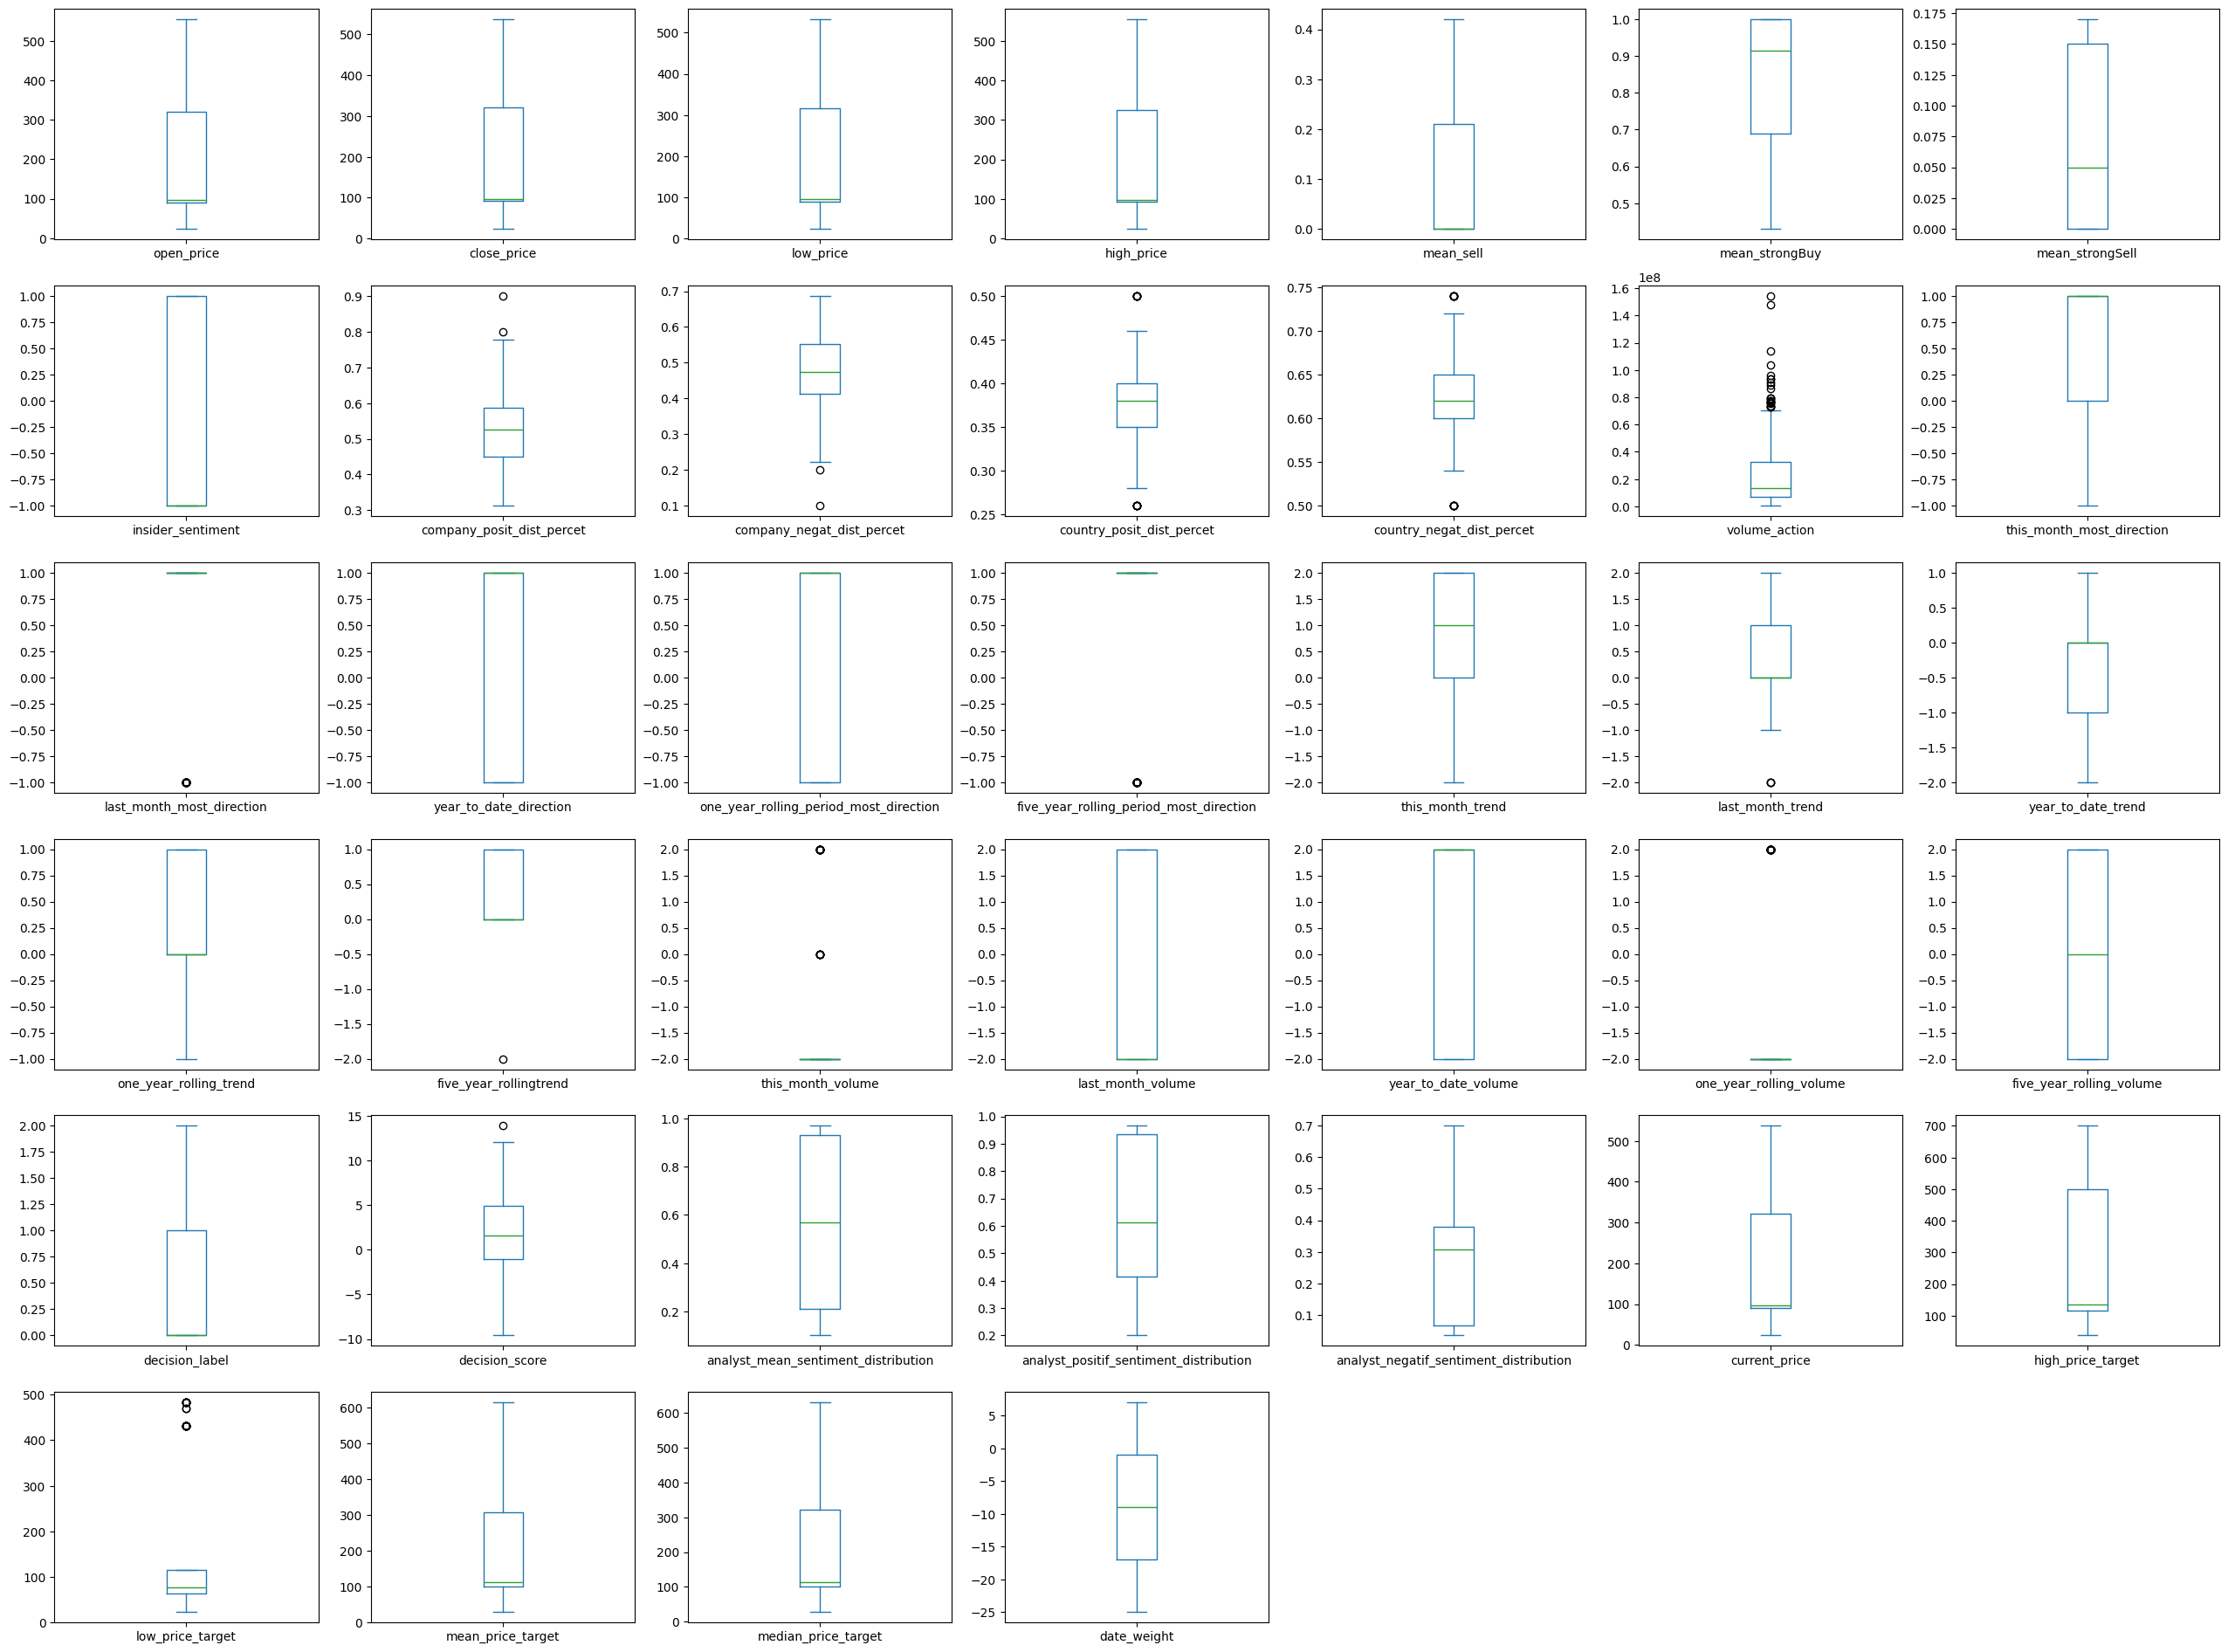

In [7]:
encode_dataset.plot(kind='box', subplots=True, layout=(6,7), sharex=False, sharey=False, figsize=(8*4, 6*4))

## train test_split

- Cas multi-classes → toujours utiliser stratify=y dans train_test_split pour que la répartition des classes soit conservée.
- test_size à 0.25 car dataset petit

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    stratify=y 
)

In [9]:
# from collections import Counter
# Counter(y_test)
# Counter(y_train)

#### dataset petit et déséquilibré (3 classes).
- scikit-learn (LR / SVC / RF) : class_weight="balanced".
- XGBoost (multi-classes) : pas de class_weight natif → passe sample_weight à fit() (poids = 1 / fréquence de classe).

In [10]:
models = {}
params_models_dict = {}

# LogisticRegression
models["LogisticRegression"] = LogisticRegression(multi_class="multinomial", solver="lbfgs", class_weight="balanced", max_iter=2000, n_jobs=None)
params_models_dict["LogisticRegression"] = logreg_grid = {
    "clf__penalty": ["l2"],                  # L2 robuste
    "clf__C": [0.1, 0.5, 1.0, 2.0],         # régularisation légère → moyenne
    "clf__solver": ["lbfgs"],               # multinomial OK
    "clf__multi_class": ["multinomial"],
    "clf__class_weight": ["balanced"],
    "clf__max_iter": [1000, 2000]
}


# SVC
models["SVC"] = SVC(kernel="rbf", class_weight="balanced", probability=False)
params_models_dict["SVC"] = svc_grid = {
    "clf__kernel": ["rbf"],
    "clf__C": [0.5, 1.0, 2.0, 5.0],         # gamme courte
    "clf__gamma": ["scale", 0.1, 0.01],     # RBF width
    "clf__class_weight": ["balanced"]
}


# RandomForestClassifier
models["RandomForestClassifier"] = RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample", random_state=42, n_jobs=-1)
params_models_dict["RandomForestClassifier"] = rf_grid = {
    "clf__n_estimators": [200, 400, 600],   # petit → 200–600 suffit
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", 0.5],     # sous-échantillonnage des features
    "clf__class_weight": ["balanced_subsample"],
    "clf__random_state": [42]
}


# xgb
models["xgb"] = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", tree_method="hist")
params_models_dict["xgb"] = xgb_grid = {
    "clf__objective": ["multi:softprob"],
    "clf__num_class": [3],                 # 3 classes
    "clf__n_estimators": [200, 400],       # peu d’arbres + early stopping
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.03, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_lambda": [1.0, 2.0],         # L2
    "clf__min_child_weight": [1, 5],
    "clf__tree_method": ["hist"],
    "clf__random_state": [42]
}

In [11]:
def needs_scaling(model_name: str) -> bool:
    """Retourne True si un StandardScaler est requis (LR/SVC)."""
    return model_name in {"LogisticRegression", "SVC"}

def run_multi_gridsearch(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    models: Dict[str, Any],
    params_models_dict: Dict[str, Dict[str, Any]],
    random_state: int = 42,
    n_splits: int = 5,
    scoring: Dict[str, str] | str = "f1_macro",  # accepte str OU dict
    refit: str | bool = "f1_macro",              # si dict → clé à utiliser, sinon True/False
    use_sample_weight_for_xgb: bool = True
) -> Dict[str, Any]:
    """
    Lance un GridSearch pour chaque modèle :
      - ajoute automatiquement StandardScaler pour LR/SVC,
      - 'passthrough' pour RF/XGB,
      - CV stratifiée,
      - renvoie un leaderboard + les meilleurs objets par modèle.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

    rows = []
    best_per_model = {}

    for name, est in models.items():
        prep = StandardScaler() if needs_scaling(name) else "passthrough"
        pipe = Pipeline([("prep", prep), ("clf", est)])

        grid = params_models_dict[name]

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=scoring,       # peut être "f1_macro" ou {"acc":"accuracy","f1_macro":"f1_macro"}
            cv=cv,
            n_jobs=-1,
            refit=refit,           # si scoring est dict → ex. "f1_macro"
            verbose=0,
            return_train_score=False
        )

        fit_kwargs = {}
        if use_sample_weight_for_xgb and name.lower().startswith("xgb"):
            fit_kwargs = {"clf__sample_weight": sample_weight}

        gs.fit(X_train, y_train, **fit_kwargs)

        # Récup CV scores (selon le type de scoring)
        if isinstance(scoring, dict):
            # on lit les deux métriques si présentes
            mean_acc = gs.cv_results_.get("mean_test_acc", [np.nan])[gs.best_index_]
            mean_f1  = gs.cv_results_.get("mean_test_f1_macro", [np.nan])[gs.best_index_]
            cv_key_for_leaderboard = refit if isinstance(refit, str) else "f1_macro"
            cv_best = gs.best_score_  # score refit
        else:
            # scoring est un str (ex. "f1_macro")
            mean_acc = np.nan
            mean_f1  = gs.best_score_ if scoring == "f1_macro" else np.nan
            cv_key_for_leaderboard = scoring
            cv_best = gs.best_score_

        # Perf test
        y_pred = gs.best_estimator_.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1  = f1_score(y_test, y_pred, average="macro")

        best_per_model[name] = gs.best_estimator_
        rows.append({
            "model": name,
            "best_params": gs.best_params_,
            f"cv_{cv_key_for_leaderboard}": cv_best,
            "cv_mean_acc": mean_acc,
            "cv_mean_f1_macro": mean_f1,
            "test_acc": test_acc,
            "test_f1_macro": test_f1
        })

    leaderboard = pd.DataFrame(rows).sort_values(
        by=[col for col in [f"cv_{refit}" if isinstance(refit, str) else f"cv_{scoring}"] if col in rows[0]],
        ascending=False
    ).reset_index(drop=True)

    return {"leaderboard": leaderboard, "best_per_model": best_per_model}


In [12]:
scores = {"acc": "accuracy", "f1_macro": "f1_macro"}

# cross validation
min_cv_folds=5
min_class_count = pd.Series(y_train).value_counts().min()
cv_folds = max(3, min(min_cv_folds, min_class_count))

out = run_multi_gridsearch(
    X_train, y_train, X_test, y_test,
    models, params_models_dict,
    n_splits=cv_folds,
    scoring=scores, refit="f1_macro"
)

c:\Users\cleme\Documents\Ynov\M2\Projet Master\Projet Bourse\NEW\Projet_master\EnvBourseMachineLearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [13]:
out["leaderboard"]

,model,best_params,cv_f1_macro,cv_mean_acc,cv_mean_f1_macro,test_acc,test_f1_macro
0,xgb,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.984730,0.986437,0.984730,0.98,0.971781
1,RandomForestClassifier,"{'clf__class_weight': 'balanced_subsample', 'c...",0.968254,0.980000,0.968254,0.98,0.971781
2,LogisticRegression,"{'clf__C': 2.0, 'clf__class_weight': 'balanced...",0.915990,0.919540,0.915990,0.96,0.953698
3,SVC,"{'clf__C': 2.0, 'clf__class_weight': 'balanced...",0.869691,0.865057,0.869691,0.90,0.902026


In [14]:
# print(out["best_per_model"])

---